In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("../data/processed/ecommerce_validated.csv")

In [23]:
df.head()

,order_id,customer_id,customer_name,city,product_category,price,quantity,payment_method,order_date,delivery_days,rating
0,ORD100000,CUS5064,Stephanie Sellers,East Deborah,Sports,754.66,2,Net Banking,2026-01-22,3,4.2
1,ORD100001,CUS2698,Michael Serrano,Longtown,Clothing,4555.67,4,Debit Card,2024-04-22,7,2.7
2,ORD100002,CUS3200,Brenda Jefferson,Lake Donald,Clothing,1279.42,2,Debit Card,2024-05-11,6,4.8
3,ORD100003,CUS3731,Michelle Singleton,New Patriciamouth,Clothing,3380.20,4,UPI,2025-06-13,1,4.7
4,ORD100004,CUS3085,Jack Johnson,Erictown,Home,3795.27,2,Net Banking,2025-05-05,4,3.2


In [24]:
df.shape

(10000, 11)

In [25]:
round(df.describe(),2)

,price,quantity,delivery_days,rating
count,10000.00,10000.00,10000.00,10000.00
mean,2524.82,2.99,4.02,3.00
std,1411.98,1.41,2.00,1.13
min,100.21,1.00,1.00,1.00
25%,1290.69,2.00,2.00,2.00
50%,2509.40,3.00,4.00,3.00
75%,3741.37,4.00,6.00,4.00
max,4999.98,5.00,7.00,5.00


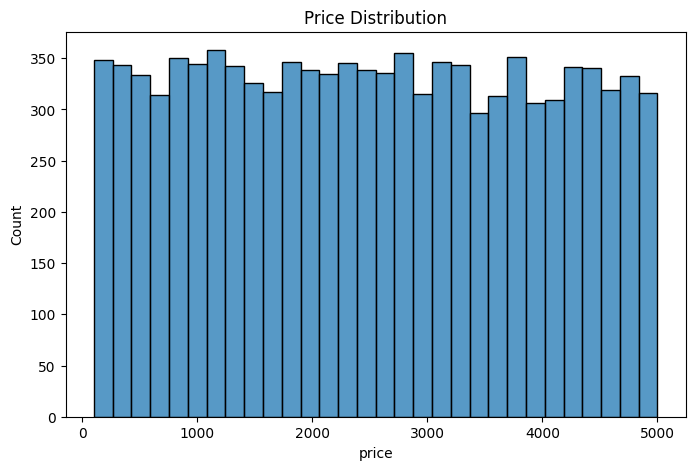

In [ ]:
#Plot price distribution.
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30)
plt.title("Price Distribution")
plt.show()

In [ ]:
#Product Category Analysis
df["product_category"].value_counts()

product_category
Electronics    1948
Books          1637
Clothing       1621
Home           1608
Beauty         1596
Sports         1590
Name: count, dtype: int64

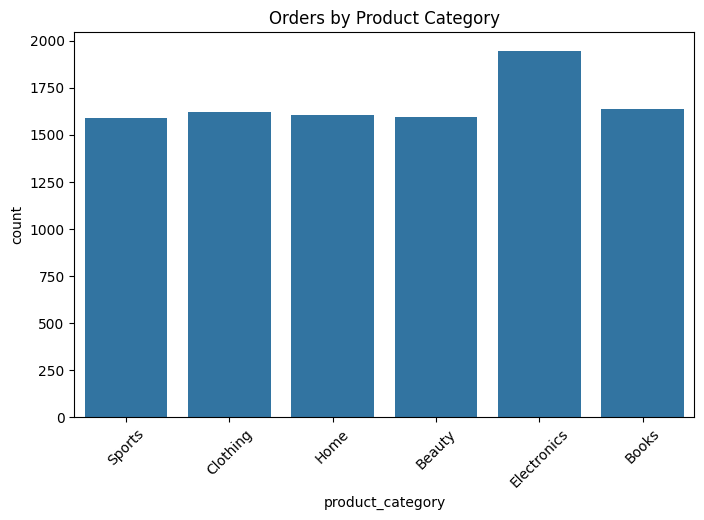

In [28]:
#visualize
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="product_category")
plt.title("Orders by Product Category")
plt.xticks(rotation=45)
plt.show()

In [29]:
# Payment Method Analysis
df["payment_method"].value_counts()

payment_method
Credit Card         2041
Cash on Delivery    2028
UPI                 2010
Debit Card          1999
Net Banking         1922
Name: count, dtype: int64

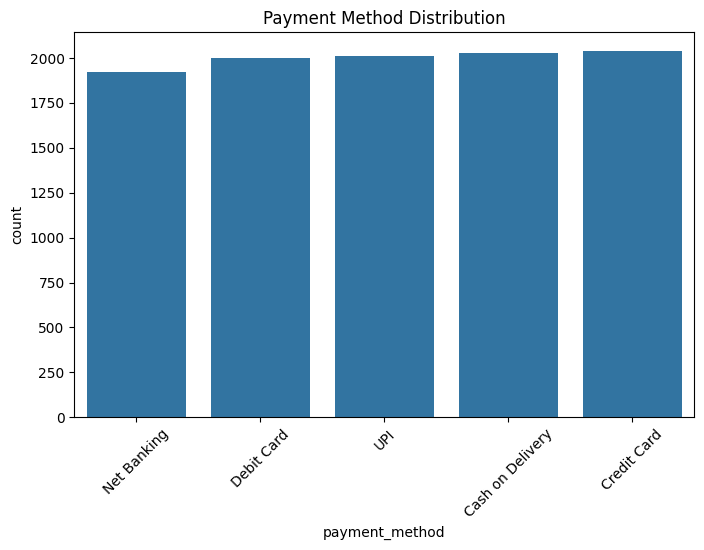

In [30]:
#visualize
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="payment_method")
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

In [38]:
# Average Rating by Category
df.groupby("product_category")["rating"].mean()

product_category
Beauty         3.040508
Books          3.006500
Clothing       2.996827
Electronics    2.999750
Home           2.994675
Sports         2.991099
Name: rating, dtype: float64

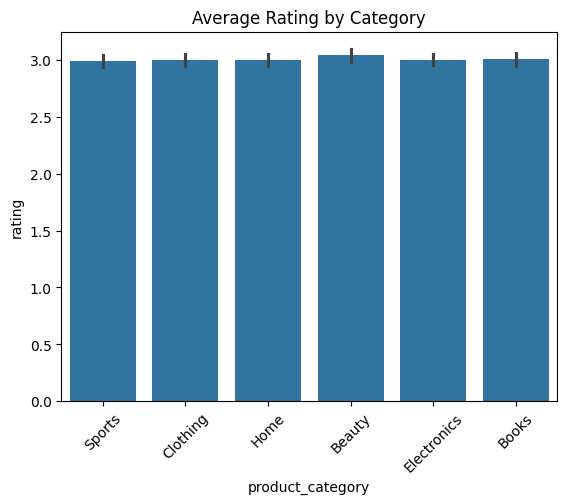

In [33]:
#visualize
sns.barplot(data=df, x="product_category", y="rating")
plt.title("Average Rating by Category")
plt.xticks(rotation=45)
plt.show()

# Advance EDA

In [34]:
df["revenue"] = df["price"] * df["quantity"]

df.head()

,order_id,customer_id,customer_name,city,product_category,price,quantity,payment_method,order_date,delivery_days,rating,revenue
0,ORD100000,CUS5064,Stephanie Sellers,East Deborah,Sports,754.66,2,Net Banking,2026-01-22,3,4.2,1509.32
1,ORD100001,CUS2698,Michael Serrano,Longtown,Clothing,4555.67,4,Debit Card,2024-04-22,7,2.7,18222.68
2,ORD100002,CUS3200,Brenda Jefferson,Lake Donald,Clothing,1279.42,2,Debit Card,2024-05-11,6,4.8,2558.84
3,ORD100003,CUS3731,Michelle Singleton,New Patriciamouth,Clothing,3380.20,4,UPI,2025-06-13,1,4.7,13520.80
4,ORD100004,CUS3085,Jack Johnson,Erictown,Home,3795.27,2,Net Banking,2025-05-05,4,3.2,7590.54


In [36]:
#Total revenue
int(df["revenue"].sum())

75392446

In [39]:
#revenue by product categories
category_revenue=df.groupby("product_category")["revenue"].sum()
category_revenue


product_category
Beauty         12190442.42
Books          12353946.55
Clothing       11958188.62
Electronics    14329460.06
Home           12532533.60
Sports         12027875.73
Name: revenue, dtype: float64

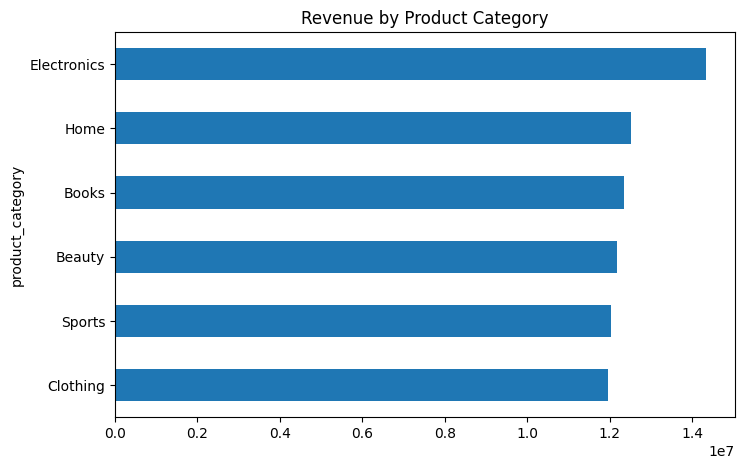

In [40]:
#Electronics generates the highest revenue.
#visualise
plt.figure(figsize=(8,5))
category_revenue.sort_values().plot(kind="barh")
plt.title("Revenue by Product Category")
plt.show()

In [42]:
#AOV(AVERAGE ORDER VALUE)
round(df["revenue"].mean(),2)

np.float64(7539.24)

In [43]:
#City Wise Sales
city_sales=df.groupby("city")["revenue"].sum().sort_values(ascending=False)
city_sales.head(10)

city
South Michael    116613.85
West Amanda       85373.10
Thomasville       84199.79
New Michael       78391.17
West Matthew      75537.51
West Jessica      73854.08
Port Kyle         70617.56
Port Lisa         70339.90
Jennifermouth     68582.83
West Richard      68237.37
Name: revenue, dtype: float64

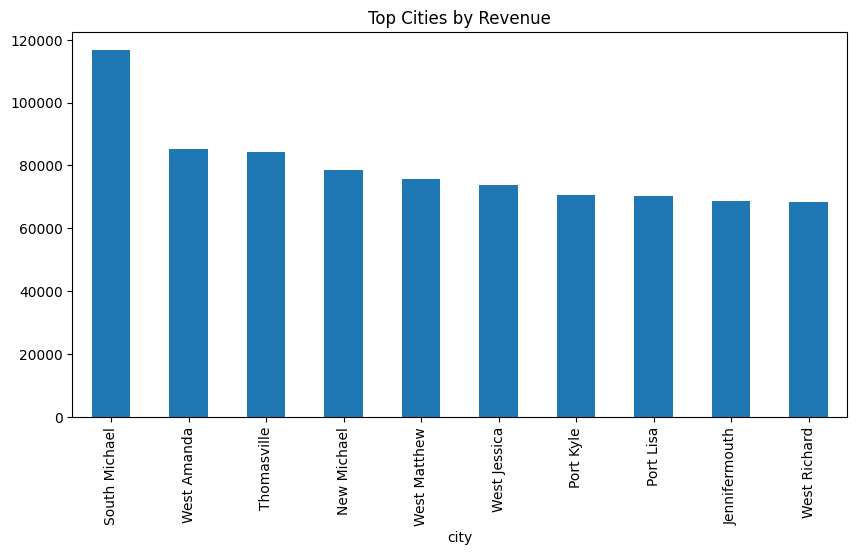

In [ ]:
#visualise
plt.figure(figsize=(10,5))
city_sales.head(10).plot(kind="bar")
plt.title("Top Cities by Revenue")
plt.show()
#Major metropolitan cities generate the highest sales.

#  Correlation Analysis

In [45]:
df[["price","quantity","rating","revenue"]].corr()

,price,quantity,rating,revenue
price,1.000000,-0.005513,0.000108,0.718163
quantity,-0.005513,1.000000,0.001137,0.603183
rating,0.000108,0.001137,1.000000,-0.001753
revenue,0.718163,0.603183,-0.001753,1.000000


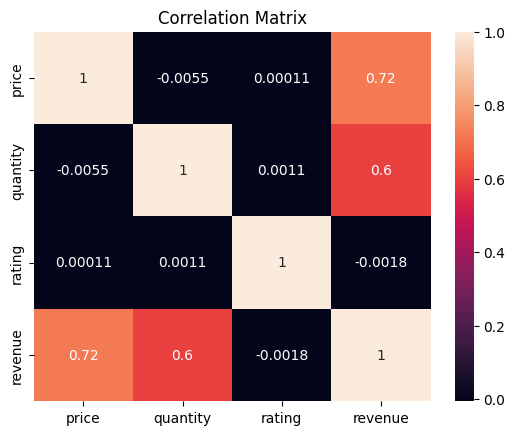

In [46]:
#visualize
sns.heatmap(df[["price","quantity","rating","revenue"]].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

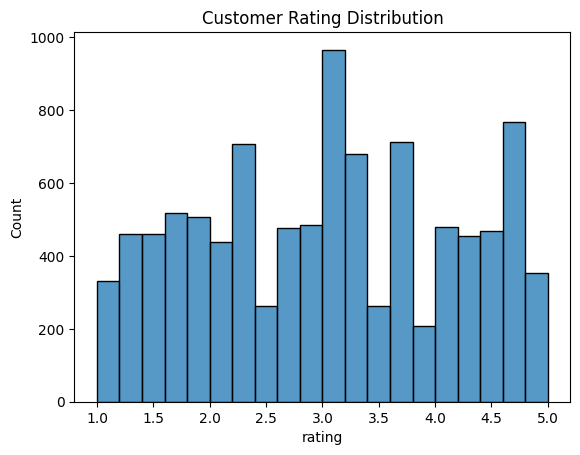

In [48]:
#Rating Distribution
sns.histplot(df["rating"], bins=20)
plt.title("Customer Rating Distribution")
plt.show()

In [ ]:
# Most ratings fall between 3.5 and 5.

# Customer Behaviour Analysis

#Total Spending per Customer


In [52]:
#Total Spending per Customer and top 10 customers
customer_spending=df.groupby("customer_id")["revenue"].sum()

customer_spending.head(10)

customer_id
CUS1000    13872.12
CUS1001     4835.13
CUS1002    15161.61
CUS1003    11213.44
CUS1005     1695.06
CUS1006     4491.90
CUS1007    27361.22
CUS1008     8773.70
CUS1009    17394.00
CUS1011     3934.76
Name: revenue, dtype: float64

In [55]:
#TOP 10 CUSTOMERS
top_customers=customer_spending.sort_values(ascending=False).head(10)
top_customers

customer_id
CUS2272    76896.25
CUS1516    70675.00
CUS7879    65632.88
CUS4788    65552.60
CUS5718    64079.65
CUS1738    62812.96
CUS6264    62751.81
CUS7878    62657.78
CUS4874    61909.37
CUS6404    61566.15
Name: revenue, dtype: float64

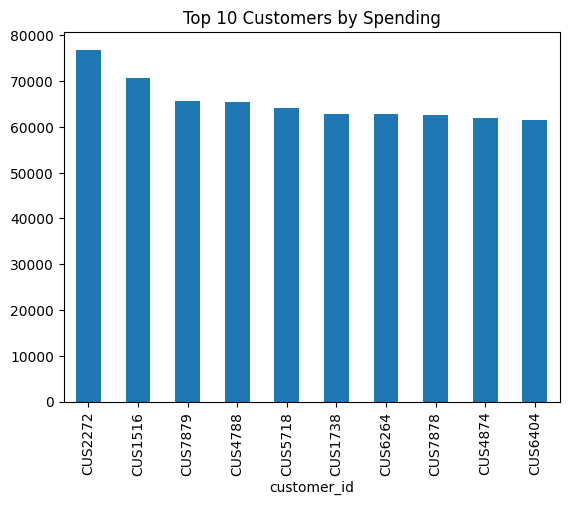

In [56]:
#visulaise
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Spending")
plt.show()

In [57]:
# Orders per Customer
customer_orders = df.groupby("customer_id")["order_id"].count()

customer_orders.head()

customer_id
CUS1000    2
CUS1001    1
CUS1002    2
CUS1003    1
CUS1005    1
Name: order_id, dtype: int64

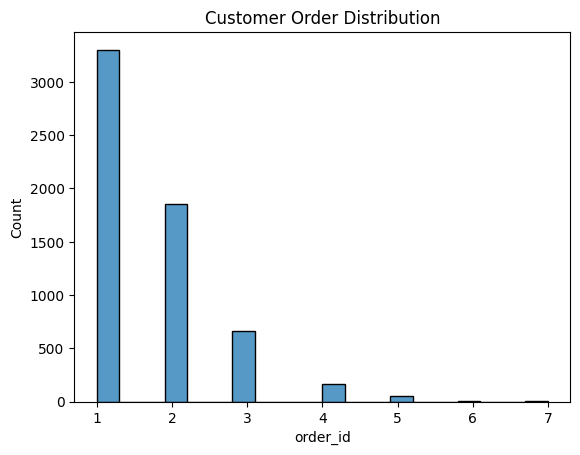

In [59]:
#visualization
sns.histplot(customer_orders, bins=20)
plt.title("Customer Order Distribution")
plt.show()

In [61]:
# Average Customer Spending
round(customer_spending.mean(),2)

np.float64(12455.39)

# Create Customer Features Table for future Machine learning

In [62]:
customer_features = df.groupby("customer_id").agg(
    total_spent=("revenue","sum"),
    total_orders=("order_id","count"),
    avg_rating=("rating","mean")
)

customer_features.head()

,total_spent,total_orders,avg_rating
customer_id,,,
CUS1000,13872.12,2,3.250000
CUS1001,4835.13,1,3.500000
CUS1002,15161.61,2,3.302347
CUS1003,11213.44,1,1.800000
CUS1005,1695.06,1,1.900000


In [63]:
#Save Customer Features
customer_features.to_csv("../data/processed/customer_features.csv")